In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#customers

In [5]:
customers=pd.read_csv(r"C:\Users\aksha\OneDrive\Documents\Data Science\DS Project\Ratails Analytics\customers.csv")

In [6]:
customers.head()

,customer_id,first_name,last_name,gender,age,signup_date,region
0,C0000,Patrick,Morgan,Male,18.0,2024-07-11,South
1,C0001,Eric,Lee,Other,36.0,2020-09-20,East
2,C0002,Thomas,Pena,Female,NaN,2021-03-07,East
3,C0003,Dalton,Duran,Male,24.0,2021-08-29,South
4,C0004,Travis,Mcclain,Male,50.0,2023-03-29,South


In [7]:
customers.tail()

,customer_id,first_name,last_name,gender,age,signup_date,region
811,C0476,John,Le,Female,29.0,2022-11-23,West
812,C0059,Alison,Berger,Male,56.0,2020-11-16,West
813,C0600,Timothy,Cunningham,Male,39.0,2021-04-24,South
814,C0480,Matthew,Moore,Female,27.0,2020-05-23,South
815,C0515,Elizabeth,Alvarez,Other,46.0,2023-07-22,East


In [8]:
customers.describe()

,age
count,776.000000
mean,44.074742
std,15.316349
min,18.000000
25%,31.000000
50%,44.000000
75%,58.000000
max,70.000000


In [9]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  816 non-null    object 
 1   first_name   816 non-null    object 
 2   last_name    816 non-null    object 
 3   gender       816 non-null    object 
 4   age          776 non-null    float64
 5   signup_date  816 non-null    object 
 6   region       816 non-null    object 
dtypes: float64(1), object(6)
memory usage: 44.8+ KB


In [10]:
customers.shape

(816, 7)

In [11]:
customers.isnull().sum()

customer_id     0
first_name      0
last_name       0
gender          0
age            40
signup_date     0
region          0
dtype: int64

In [12]:
customers.duplicated().sum()

16

In [13]:
customers_cleaned = customers.copy()

In [14]:
customers_cleaned = customers_cleaned.drop_duplicates().reset_index(drop=True)

In [15]:
customers_cleaned.columns

Index(['customer_id', 'first_name', 'last_name', 'gender', 'age',
       'signup_date', 'region'],
      dtype='object')

In [16]:
customers_cleaned['age'] = customers_cleaned['age'].fillna(
    customers_cleaned['age'].mean()
).astype(int)

In [17]:
customers_cleaned['customer_id'] = customers_cleaned['customer_id'].astype("string")
customers_cleaned['first_name'] = customers_cleaned['first_name'].astype("string")
customers_cleaned['last_name'] = customers_cleaned['last_name'].astype("string")
customers_cleaned['gender'] = customers_cleaned['gender'].astype("string")
customers_cleaned['region'] = customers_cleaned['region'].astype("string")
customers_cleaned['age'] = customers_cleaned['age'].astype("Int64")
customers_cleaned['signup_date']=pd.to_datetime(customers_cleaned['signup_date'])
customers_cleaned['age'] = pd.to_numeric(customers_cleaned['age'], errors='coerce')
customers_cleaned['age'] = customers_cleaned['age'].round()

In [18]:
customers_cleaned.head()

,customer_id,first_name,last_name,gender,age,signup_date,region
0,C0000,Patrick,Morgan,Male,18,2024-07-11,South
1,C0001,Eric,Lee,Other,36,2020-09-20,East
2,C0002,Thomas,Pena,Female,44,2021-03-07,East
3,C0003,Dalton,Duran,Male,24,2021-08-29,South
4,C0004,Travis,Mcclain,Male,50,2023-03-29,South


In [19]:
customers_cleaned.tail()

,customer_id,first_name,last_name,gender,age,signup_date,region
795,C0795,Emily,Smith,Male,42,2025-04-03,South
796,C0796,Jonathan,Gardner,Other,20,2023-03-08,South
797,C0797,Jordan,Smith,Other,56,2020-04-29,West
798,C0798,Rachel,Porter,Other,39,2020-08-12,South
799,C0799,Jeffrey,Myers,Female,44,2024-06-12,North


In [20]:
customers_cleaned.isna().sum()

customer_id    0
first_name     0
last_name      0
gender         0
age            0
signup_date    0
region         0
dtype: int64

In [21]:
customers_cleaned.head()

,customer_id,first_name,last_name,gender,age,signup_date,region
0,C0000,Patrick,Morgan,Male,18,2024-07-11,South
1,C0001,Eric,Lee,Other,36,2020-09-20,East
2,C0002,Thomas,Pena,Female,44,2021-03-07,East
3,C0003,Dalton,Duran,Male,24,2021-08-29,South
4,C0004,Travis,Mcclain,Male,50,2023-03-29,South


In [22]:
customers_cleaned.dtypes

customer_id    string[python]
first_name     string[python]
last_name      string[python]
gender         string[python]
age                     Int64
signup_date    datetime64[ns]
region         string[python]
dtype: object

In [23]:
#products

In [24]:
products=pd.read_csv(r"C:\Users\aksha\OneDrive\Documents\Data Science\DS Project\Ratails Analytics\products.csv")

In [25]:
products.head()

,product_id,product_name,category,brand,cost_price,unit_price,margin_pct
0,P0000,BrandA Shoulder,Electronics,BrandC,52.75,64.65,18.41
1,P0001,BrandA Responsibility,Electronics,BrandD,11.20,13.26,15.54
2,P0002,BrandB Small,Electronics,BrandB,144.62,250.37,42.24
3,P0003,BrandD Continue,Apparel,BrandD,119.91,219.25,45.31
4,P0004,BrandA Indeed,Apparel,BrandD,71.35,88.47,19.35


In [26]:
products.head()

,product_id,product_name,category,brand,cost_price,unit_price,margin_pct
0,P0000,BrandA Shoulder,Electronics,BrandC,52.75,64.65,18.41
1,P0001,BrandA Responsibility,Electronics,BrandD,11.20,13.26,15.54
2,P0002,BrandB Small,Electronics,BrandB,144.62,250.37,42.24
3,P0003,BrandD Continue,Apparel,BrandD,119.91,219.25,45.31
4,P0004,BrandA Indeed,Apparel,BrandD,71.35,88.47,19.35


In [27]:
products.describe()

,cost_price,unit_price,margin_pct
count,1224.000000,1224.000000,1224.000000
mean,103.030016,159.559428,33.869158
std,55.981671,90.679397,11.267576
min,5.290000,6.770000,9.120000
25%,54.697500,83.887500,25.397500
50%,104.490000,157.590000,36.260000
75%,151.342500,226.220000,43.135000
max,199.470000,382.320000,49.990000


In [28]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1224 entries, 0 to 1223
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    1224 non-null   object 
 1   product_name  1224 non-null   object 
 2   category      1224 non-null   object 
 3   brand         1164 non-null   object 
 4   cost_price    1224 non-null   float64
 5   unit_price    1224 non-null   float64
 6   margin_pct    1224 non-null   float64
dtypes: float64(3), object(4)
memory usage: 67.1+ KB


In [29]:
products.shape

(1224, 7)

In [30]:
products.isnull().sum()

product_id       0
product_name     0
category         0
brand           60
cost_price       0
unit_price       0
margin_pct       0
dtype: int64

In [31]:
products.duplicated().sum()

24

In [32]:
products_cleaned = products.copy()

In [33]:
products_cleaned = products.drop_duplicates().reset_index(drop=True)

In [34]:
products_cleaned.columns

Index(['product_id', 'product_name', 'category', 'brand', 'cost_price',
       'unit_price', 'margin_pct'],
      dtype='object')

In [35]:
products_cleaned.loc[:, 'brand'] = products_cleaned['brand'].fillna('Unknown')

In [36]:
products_cleaned['product_id'] = products_cleaned['product_id'].astype("string")
products_cleaned['product_name'] = products_cleaned['product_name'].astype("string")
products_cleaned['category'] = products_cleaned['category'].astype("string")
products_cleaned['brand'] = products_cleaned['brand'].astype("string")

In [37]:
products_cleaned.head()

,product_id,product_name,category,brand,cost_price,unit_price,margin_pct
0,P0000,BrandA Shoulder,Electronics,BrandC,52.75,64.65,18.41
1,P0001,BrandA Responsibility,Electronics,BrandD,11.20,13.26,15.54
2,P0002,BrandB Small,Electronics,BrandB,144.62,250.37,42.24
3,P0003,BrandD Continue,Apparel,BrandD,119.91,219.25,45.31
4,P0004,BrandA Indeed,Apparel,BrandD,71.35,88.47,19.35


In [38]:
products_cleaned.tail()

,product_id,product_name,category,brand,cost_price,unit_price,margin_pct
1195,P1195,BrandB Challenge,Home & Kitchen,BrandB,15.31,21.82,29.84
1196,P1196,BrandC Better,Electronics,BrandC,61.87,103.64,40.30
1197,P1197,BrandA Own,Apparel,BrandB,154.11,252.57,38.98
1198,P1198,BrandB Your,Home & Kitchen,BrandC,166.23,285.33,41.74
1199,P1199,BrandC Door,Home & Kitchen,BrandC,23.69,38.43,38.36


In [39]:
products_cleaned.isna().sum()

product_id      0
product_name    0
category        0
brand           0
cost_price      0
unit_price      0
margin_pct      0
dtype: int64

In [40]:
products_cleaned.dtypes

product_id      string[python]
product_name    string[python]
category        string[python]
brand           string[python]
cost_price             float64
unit_price             float64
margin_pct             float64
dtype: object

In [41]:
products_cleaned.head()

,product_id,product_name,category,brand,cost_price,unit_price,margin_pct
0,P0000,BrandA Shoulder,Electronics,BrandC,52.75,64.65,18.41
1,P0001,BrandA Responsibility,Electronics,BrandD,11.20,13.26,15.54
2,P0002,BrandB Small,Electronics,BrandB,144.62,250.37,42.24
3,P0003,BrandD Continue,Apparel,BrandD,119.91,219.25,45.31
4,P0004,BrandA Indeed,Apparel,BrandD,71.35,88.47,19.35


In [42]:
#returns

In [43]:
returns=pd.read_csv(r"C:\Users\aksha\OneDrive\Documents\Data Science\DS Project\Ratails Analytics\returns.csv")

In [44]:
returns.head()

,return_id,order_id,return_date,return_reason
0,R0000,O02237,2024-03-05,Defective
1,R0001,O01700,2025-03-18,Defective
2,R0002,O01451,2025-02-18,Late Delivery
3,R0003,O02759,2023-10-26,Defective
4,R0004,O00415,2024-08-06,No Longer Needed


In [45]:
returns.tail()

,return_id,order_id,return_date,return_reason
199,R0199,O01305,2025-01-26,No Longer Needed
200,R0182,O00585,2024-08-24,Late Delivery
201,R0156,O01596,2024-01-27,No Longer Needed
202,R0194,O00934,2024-09-09,Wrong Item
203,R0035,O02071,2023-08-10,Defective


In [46]:
returns.describe()

,return_id,order_id,return_date,return_reason
count,204,204,204,204
unique,200,193,176,4
top,R0194,O00362,2023-08-10,Defective
freq,2,3,4,64


In [47]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   return_id      204 non-null    object
 1   order_id       204 non-null    object
 2   return_date    204 non-null    object
 3   return_reason  204 non-null    object
dtypes: object(4)
memory usage: 6.5+ KB


In [48]:
returns.isna().sum()

return_id        0
order_id         0
return_date      0
return_reason    0
dtype: int64

In [49]:
returns.duplicated().sum()

4

In [50]:
returns.columns

Index(['return_id', 'order_id', 'return_date', 'return_reason'], dtype='object')

In [51]:
returns_cleaned = returns.copy()

In [52]:
returns_cleaned = returns.drop_duplicates().reset_index(drop=True)

In [53]:
returns_cleaned.duplicated().sum()

0

In [54]:
returns_cleaned['return_id'] = returns_cleaned['return_id'].astype("string")
returns_cleaned['order_id'] = returns_cleaned['order_id'].astype("string")
returns_cleaned['return_reason'] = returns_cleaned['return_reason'].astype("string")
returns_cleaned['return_date']=pd.to_datetime(returns_cleaned['return_date'])

In [55]:
returns_cleaned.isna().sum()

return_id        0
order_id         0
return_date      0
return_reason    0
dtype: int64

In [56]:
returns_cleaned.duplicated().sum()

0

In [57]:
returns_cleaned.dtypes

return_id        string[python]
order_id         string[python]
return_date      datetime64[ns]
return_reason    string[python]
dtype: object

In [58]:
returns_cleaned.head()

,return_id,order_id,return_date,return_reason
0,R0000,O02237,2024-03-05,Defective
1,R0001,O01700,2025-03-18,Defective
2,R0002,O01451,2025-02-18,Late Delivery
3,R0003,O02759,2023-10-26,Defective
4,R0004,O00415,2024-08-06,No Longer Needed


In [59]:
#sales

In [60]:
sales=pd.read_csv(r"C:\Users\aksha\OneDrive\Documents\Data Science\DS Project\Ratails Analytics\sales_data.csv")

In [61]:
sales.head()

,order_id,order_date,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,total_amount
0,O00000,2024-01-31,C0125,P1086,NaN,Online,2,80.63,0.05,153.20
1,O00001,2024-09-29,C0633,P0973,S042,In-Store,20,209.16,0.05,3974.00
2,O00002,2023-08-29,C0653,P0659,NaN,Online,2,218.60,0.10,393.48
3,O00003,2024-05-13,C0753,P0666,S014,In-Store,1,78.53,0.20,62.82
4,O00004,2024-07-22,C0627,P0166,S017,In-Store,1,344.93,0.20,275.94


In [62]:
sales.tail()

,order_id,order_date,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,total_amount
3055,O02044,2024-09-26,C0580,P0886,S024,In-Store,2,82.92,0.00,165.84
3056,O02352,2023-11-16,C0632,P0091,S034,In-Store,1,27.29,0.10,24.56
3057,O02014,2023-06-25,C0127,P0296,NaN,Online,3,34.89,0.00,104.67
3058,O01371,2025-02-12,C0741,P1056,NaN,Online,1,57.51,0.05,54.63
3059,O00797,2025-03-27,C0479,P0659,NaN,Online,10,218.60,0.10,1967.40


In [63]:
sales.describe()

,quantity,unit_price,discount_pct,total_amount
count,3060.000000,3060.000000,3060.000000,3060.000000
mean,1.816340,160.494961,0.088056,272.423582
std,1.749869,91.106112,0.074714,411.177912
min,1.000000,6.770000,0.000000,6.970000
25%,1.000000,83.700000,0.050000,107.467500
50%,2.000000,161.170000,0.050000,196.580000
75%,2.000000,229.100000,0.200000,337.460000
max,30.000000,382.320000,0.200000,8855.800000


In [64]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3060 entries, 0 to 3059
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       3060 non-null   object 
 1   order_date     3060 non-null   object 
 2   customer_id    3060 non-null   object 
 3   product_id     3060 non-null   object 
 4   store_id       2068 non-null   object 
 5   sales_channel  3060 non-null   object 
 6   quantity       3060 non-null   int64  
 7   unit_price     3060 non-null   float64
 8   discount_pct   3060 non-null   float64
 9   total_amount   3060 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 239.2+ KB


In [65]:
sales.shape

(3060, 10)

In [66]:
sales.isna().sum()

order_id           0
order_date         0
customer_id        0
product_id         0
store_id         992
sales_channel      0
quantity           0
unit_price         0
discount_pct       0
total_amount       0
dtype: int64

In [67]:
sales.duplicated().sum()

60

In [68]:
sales_cleaned = sales.copy()

In [69]:
sales_cleaned = sales_cleaned.drop_duplicates().reset_index(drop=True)

In [70]:
sales_cleaned = sales_cleaned.dropna(subset=['order_id', 'product_id', 'customer_id'])

In [71]:
sales_cleaned.columns

Index(['order_id', 'order_date', 'customer_id', 'product_id', 'store_id',
       'sales_channel', 'quantity', 'unit_price', 'discount_pct',
       'total_amount'],
      dtype='object')

In [72]:
sales_cleaned['store_id'] = sales_cleaned['store_id'].fillna('-')

In [73]:
sales_cleaned['order_id'] = sales_cleaned['order_id'].astype("string")
sales_cleaned['customer_id'] = sales_cleaned['customer_id'].astype("string")
sales_cleaned['product_id'] = sales_cleaned['product_id'].astype("string")
sales_cleaned['store_id'] = sales_cleaned['store_id'].astype("string")
sales_cleaned['sales_channel'] = sales_cleaned['sales_channel'].astype("string")
sales_cleaned['order_date']=pd.to_datetime(sales_cleaned['order_date'])
sales_cleaned['quantity'] = sales_cleaned['quantity'].astype("Int64")

In [74]:
sales_cleaned.head()

,order_id,order_date,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,total_amount
0,O00000,2024-01-31,C0125,P1086,-,Online,2,80.63,0.05,153.20
1,O00001,2024-09-29,C0633,P0973,S042,In-Store,20,209.16,0.05,3974.00
2,O00002,2023-08-29,C0653,P0659,-,Online,2,218.60,0.10,393.48
3,O00003,2024-05-13,C0753,P0666,S014,In-Store,1,78.53,0.20,62.82
4,O00004,2024-07-22,C0627,P0166,S017,In-Store,1,344.93,0.20,275.94


In [75]:
sales_cleaned.tail()

,order_id,order_date,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,total_amount
2995,O02995,2025-03-09,C0346,P0972,-,Online,1,113.58,0.20,90.86
2996,O02996,2024-11-10,C0714,P0856,S047,In-Store,1,72.18,0.05,68.57
2997,O02997,2024-08-18,C0217,P0586,S021,In-Store,3,276.20,0.20,662.88
2998,O02998,2023-11-11,C0591,P0053,S006,In-Store,1,222.76,0.20,178.21
2999,O02999,2025-03-09,C0150,P0606,S037,In-Store,2,6.77,0.05,12.86


In [76]:
sales_cleaned.isna().sum()

order_id         0
order_date       0
customer_id      0
product_id       0
store_id         0
sales_channel    0
quantity         0
unit_price       0
discount_pct     0
total_amount     0
dtype: int64

In [77]:
sales_cleaned.duplicated().sum()

0

In [78]:
sales_cleaned.dtypes

order_id         string[python]
order_date       datetime64[ns]
customer_id      string[python]
product_id       string[python]
store_id         string[python]
sales_channel    string[python]
quantity                  Int64
unit_price              float64
discount_pct            float64
total_amount            float64
dtype: object

In [79]:
#stores

In [80]:
stores=pd.read_csv(r"C:\Users\aksha\OneDrive\Documents\Data Science\DS Project\Ratails Analytics\stores.csv")

In [81]:
stores.head()

,store_id,store_name,store_type,region,city,operating_cost
0,S000,Vincent Inc Store,Franchise,West,Chicago,62538.56
1,S001,Wilson Inc Store,Flagship,East,Chicago,26957.43
2,S002,Washington-Trujillo Store,Franchise,North,Los Angeles,66101.63
3,S003,Santana and Sons Store,Franchise,South,Phoenix,71089.40
4,S004,Oconnor-Rhodes Store,Franchise,East,Los Angeles,40965.26


In [82]:
stores.tail()

,store_id,store_name,store_type,region,city,operating_cost
56,S056,"Johnson, Sims and Miles Store",Mall Kiosk,East,Los Angeles,75869.37
57,S057,"Crawford, Spencer and Lopez Store",Franchise,West,Houston,52756.63
58,S058,Hubbard-Thomas Store,Mall Kiosk,East,New York,10215.93
59,S059,"Foster, Gutierrez and Li Store",Franchise,West,Los Angeles,11797.63
60,S017,Robinson PLC Store,Flagship,East,Phoenix,47603.84


In [83]:
stores.describe()

,operating_cost
count,61.000000
mean,40329.226721
std,19225.845475
min,10215.930000
25%,22350.490000
50%,39178.960000
75%,52756.630000
max,78806.300000


In [84]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   store_id        61 non-null     object 
 1   store_name      61 non-null     object 
 2   store_type      61 non-null     object 
 3   region          61 non-null     object 
 4   city            61 non-null     object 
 5   operating_cost  61 non-null     float64
dtypes: float64(1), object(5)
memory usage: 3.0+ KB


In [85]:
stores.shape

(61, 6)

In [86]:
stores.isna().sum()

store_id          0
store_name        0
store_type        0
region            0
city              0
operating_cost    0
dtype: int64

In [87]:
stores.duplicated().sum()

1

In [88]:
stores_cleaned = stores.copy()

In [89]:
stores_cleaned = stores_cleaned.drop_duplicates().reset_index(drop=True)

In [90]:
stores_cleaned['store_id']=stores_cleaned['store_id'].astype("string")
stores_cleaned['store_name']=stores_cleaned['store_name'].astype("string")
stores_cleaned['store_type']=stores_cleaned['store_type'].astype("string")
stores_cleaned['region']=stores_cleaned['region'].astype("string")
stores_cleaned['city']=stores_cleaned['city'].astype("string")

In [91]:
stores_cleaned.dtypes

store_id          string[python]
store_name        string[python]
store_type        string[python]
region            string[python]
city              string[python]
operating_cost           float64
dtype: object

In [92]:
stores_cleaned

,store_id,store_name,store_type,region,city,operating_cost
0,S000,Vincent Inc Store,Franchise,West,Chicago,62538.56
1,S001,Wilson Inc Store,Flagship,East,Chicago,26957.43
2,S002,Washington-Trujillo Store,Franchise,North,Los Angeles,66101.63
3,S003,Santana and Sons Store,Franchise,South,Phoenix,71089.40
4,S004,Oconnor-Rhodes Store,Franchise,East,Los Angeles,40965.26
5,S005,Mayer-Scott Store,Flagship,North,Houston,14898.94
6,S006,"Stewart, Lowe and Quinn Store",Flagship,North,Los Angeles,75679.22
7,S007,Marshall PLC Store,Flagship,North,Los Angeles,51484.15
8,S008,Mcdaniel-Bennett Store,Flagship,South,Phoenix,15471.52
9,S009,"Rasmussen, Meyers and Mendoza Store",Franchise,West,Chicago,21491.12


In [93]:
#derived columns

In [94]:
products_cleaned['unit_profit'] = (
    products_cleaned['unit_price'] - products_cleaned['cost_price']
)

In [95]:
sales_cleaned = sales_cleaned.merge(
    products_cleaned[['product_id', 'cost_price']],
    on='product_id',
    how='left'
)

In [96]:
# cost_price temporarily merged
sales_cleaned['profit'] = (
    sales_cleaned['total_amount'] -
    (sales_cleaned['cost_price'] * sales_cleaned['quantity'])
)

In [97]:
def age_group(age):
    if age < 25:
        return 'Under 25'
    elif age < 35:
        return '25-34'
    elif age < 50:
        return '35-49'
    else:
        return '50-+'

customers_cleaned['age_group'] = customers_cleaned['age'].apply(age_group)

In [98]:
#EDA

In [99]:
print("Total Sales:", sales_cleaned['total_amount'].sum())
print("Total Profit:", sales_cleaned['profit'].sum())

Total Sales: 818180.57
Total Profit: 243772.19


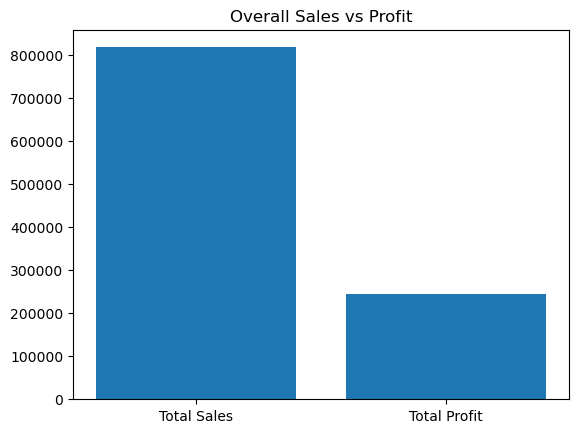

In [100]:
total_sales = sales_cleaned['total_amount'].sum()
total_profit = sales_cleaned['profit'].sum()

plt.bar(['Total Sales', 'Total Profit'], [total_sales, total_profit])
plt.title('Overall Sales vs Profit')
plt.show()

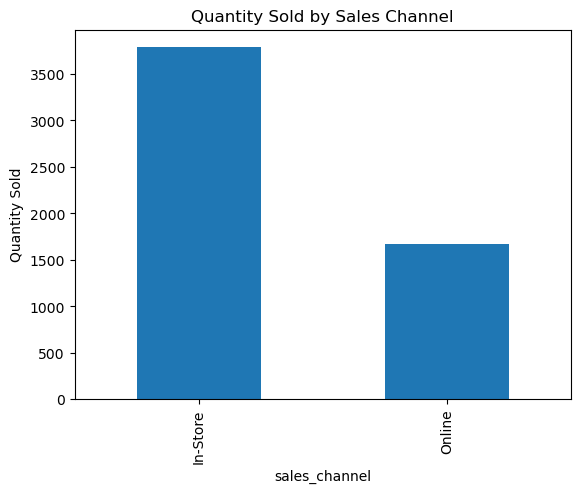

In [101]:
sales_cleaned.groupby('sales_channel')['quantity'].sum().plot(
    kind='bar', title='Quantity Sold by Sales Channel'
)
plt.ylabel('Quantity Sold')
plt.show()

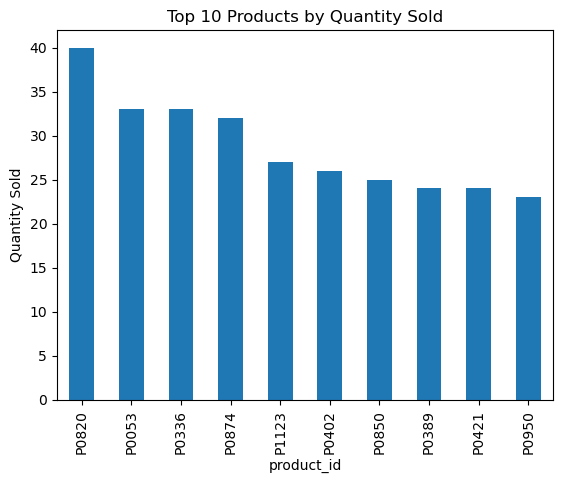

In [102]:
top_products_qty = (
    sales_cleaned.groupby('product_id')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_qty.plot(kind='bar', title='Top 10 Products by Quantity Sold')
plt.ylabel('Quantity Sold')
plt.show()

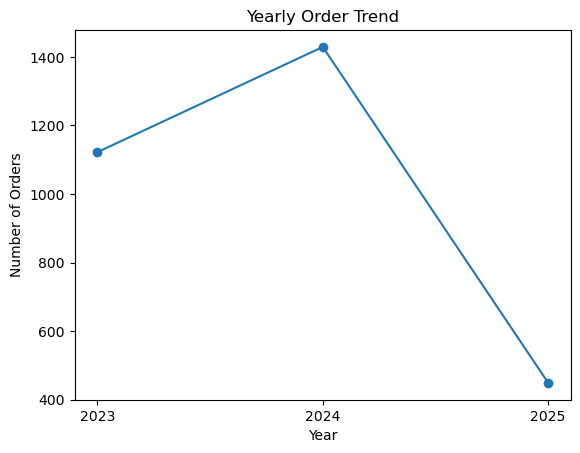

In [103]:
# Yearly sales trend (Number of orders)

sales_cleaned['order_year'] = sales_cleaned['order_date'].dt.to_period('Y')

yearly_orders = sales_cleaned.groupby('order_year')['order_id'].nunique().reset_index()
yearly_orders['order_year'] = yearly_orders['order_year'].astype('string')

plt.plot(yearly_orders['order_year'], yearly_orders['order_id'], marker='o')
plt.title('Yearly Order Trend')
plt.xlabel('Year')
plt.ylabel('Number of Orders')
plt.show()

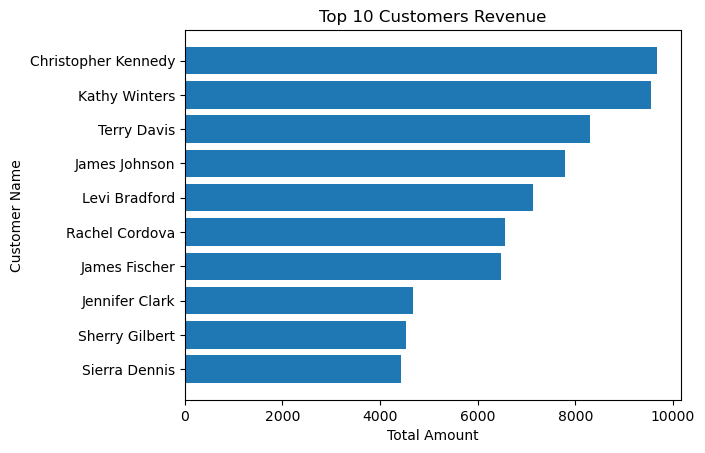

In [104]:
#Top 10 Customers Revenue 
df= sales_cleaned.merge(customers_cleaned,on='customer_id',how='left')
df['customer_name']=df['first_name']+' '+df['last_name']
top_customers=df.groupby(['customer_id','customer_name'])['total_amount'].sum().reset_index().sort_values('total_amount',ascending=False).head(10)
top_customers=top_customers.sort_values('total_amount')
plt.figure()
plt.barh(top_customers['customer_name'],top_customers['total_amount'])
plt.title("Top 10 Customers Revenue")
plt.xlabel("Total Amount")
plt.ylabel("Customer Name")
plt.show()

In [105]:
#saving cleaned files

In [106]:
sales_cleaned.to_csv('sales_cleaned.csv', index=False)
customers_cleaned.to_csv('customers_cleaned.csv', index=False)
products_cleaned.to_csv('products_cleaned.csv', index=False)
returns_cleaned.to_csv('returns_cleaned.csv', index=False)

In [107]:
stores_cleaned.to_csv('stores_cleaned.csv', index=False)

In [108]:
import os
os.getcwd()

'C:\\Users\\aksha'

In [109]:
customers.cleaned['age'] = customers['age'].fillna().mean(customers['age'])

ValueError: Must specify a fill 'value' or 'method'.